In [1]:
# Copyright (c) Meta Platforms, Inc. and affiliates.

# Depth Estimation <a target="_blank" href="https://colab.research.google.com/github/facebookresearch/dinov2/blob/main/notebooks/depth_estimation.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import sys

INSTALL = False # Switch this to install dependencies
if INSTALL: # Try installing package with extras
    REPO_URL = "https://github.com/facebookresearch/dinov2"
    PYTHON_PATH=sys.executable
    PYTHON_PATH="/home/ezalos/42/Notebooks2Teach/PreciousZoo/DINOv2/.venv/bin/python"
    
    !{PYTHON_PATH} -m pip install -e {REPO_URL}'[extras]' --extra-index-url https://download.pytorch.org/whl/cu117  --extra-index-url https://pypi.nvidia.com
else:
    REPO_PATH = "<FIXME>" # Specify a local path to the repository (or use installed package instead)
    sys.path.append(REPO_PATH)

In [3]:
LOCAL_PATH = "/home/ezalos/42/art/comfyui/swag_mirror/dinov2"
if LOCAL_PATH not in sys.path:
    sys.path.insert(0, LOCAL_PATH)
    print(f"{sys.path = }")

LOCAL_PATH = "/home/ezalos/42/Notebooks2Teach/PreciousZoo"
if LOCAL_PATH not in sys.path:
    sys.path.insert(0, LOCAL_PATH)
    print(f"{sys.path = }")

from utils.gpu_memory import measure_model_memory_impact, log_gpu_memory

sys.path = ['/home/ezalos/42/art/comfyui/swag_mirror/dinov2', '/usr/lib/python310.zip', '/usr/lib/python3.10', '/usr/lib/python3.10/lib-dynload', '', '/home/ezalos/42/art/comfyui/venv/lib/python3.10/site-packages', '<FIXME>']
sys.path = ['/home/ezalos/42/Notebooks2Teach/PreciousZoo', '/home/ezalos/42/art/comfyui/swag_mirror/dinov2', '/usr/lib/python310.zip', '/usr/lib/python3.10', '/usr/lib/python3.10/lib-dynload', '', '/home/ezalos/42/art/comfyui/venv/lib/python3.10/site-packages', '<FIXME>']


## Utilities

In [4]:
import math
import itertools
from functools import partial

import torch
import torch.nn.functional as F

from dinov2.eval.depth.models import build_depther


class CenterPadding(torch.nn.Module):
    def __init__(self, multiple):
        super().__init__()
        self.multiple = multiple

    def _get_pad(self, size):
        new_size = math.ceil(size / self.multiple) * self.multiple
        pad_size = new_size - size
        pad_size_left = pad_size // 2
        pad_size_right = pad_size - pad_size_left
        return pad_size_left, pad_size_right

    @torch.inference_mode()
    def forward(self, x):
        pads = list(itertools.chain.from_iterable(self._get_pad(m) for m in x.shape[:1:-1]))
        output = F.pad(x, pads)
        return output


@measure_model_memory_impact
def create_depther(cfg, backbone_model, backbone_size, head_type):
    train_cfg = cfg.get("train_cfg")
    test_cfg = cfg.get("test_cfg")
    depther = build_depther(cfg.model, train_cfg=train_cfg, test_cfg=test_cfg)

    depther.backbone.forward = partial(
        backbone_model.get_intermediate_layers,
        n=cfg.model.backbone.out_indices,
        reshape=True,
        return_class_token=cfg.model.backbone.output_cls_token,
        norm=cfg.model.backbone.final_norm,
    )

    if hasattr(backbone_model, "patch_size"):
        depther.backbone.register_forward_pre_hook(lambda _, x: CenterPadding(backbone_model.patch_size)(x[0]))

    return depther

## Load pretrained backbone

In [5]:
@measure_model_memory_impact
def load_backbone(backbone_size):
    # BACKBONE_SIZE = "small" # in ("small", "base", "large" or "giant")

    backbone_archs = {
		"small": "vits14",
		"base": "vitb14",
		"large": "vitl14",
		"giant": "vitg14",
	}
    backbone_arch = backbone_archs[BACKBONE_SIZE]
    backbone_name = f"dinov2_{backbone_arch}"

    backbone_model = torch.hub.load(
        repo_or_dir="facebookresearch/dinov2", model=backbone_name
    )
    backbone_model.eval()
    backbone_model.cuda()
    backbone_name = f"dinov2_{backbone_arch}"
    return backbone_model, backbone_name

BACKBONE_SIZE = "small"
backbone_model, backbone_name = load_backbone(BACKBONE_SIZE)

GPU Memory before load_backbone: [GPU-LEAK ?] Allocated: 0.00GB (Peak: 0.00GB) | Reserved: 0.00GB (Peak: 0.00GB)


Using cache found in /home/ezalos/.cache/torch/hub/facebookresearch_dinov2_main
/home/ezalos/42/art/comfyui/swag_mirror/dinov2/dinov2/layers/swiglu_ffn.py:43: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
/home/ezalos/42/art/comfyui/swag_mirror/dinov2/dinov2/layers/attention.py:27: UserWarning: xFormers is available (Attention)
  warnings.warn("xFormers is available (Attention)")
/home/ezalos/42/art/comfyui/swag_mirror/dinov2/dinov2/layers/block.py:33: UserWarning: xFormers is available (Block)
  warnings.warn("xFormers is available (Block)")


GPU Memory impact of load_backbone: [GPU-LEAK ?] Allocated: 0.08GB (Peak: 0.08GB) | Reserved: 0.11GB (Peak: 0.11GB)


## Load pretrained depth head

In [6]:
import urllib

import mmcv
from mmcv.runner import load_checkpoint


def load_config_from_url(url: str) -> str:
    with urllib.request.urlopen(url) as f:
        return f.read().decode()


HEAD_DATASET = "nyu" # in ("nyu", "kitti")
HEAD_TYPE = "dpt" # in ("linear", "linear4", "dpt")


DINOV2_BASE_URL = "https://dl.fbaipublicfiles.com/dinov2"
head_config_url = f"{DINOV2_BASE_URL}/{backbone_name}/{backbone_name}_{HEAD_DATASET}_{HEAD_TYPE}_config.py"
head_checkpoint_url = f"{DINOV2_BASE_URL}/{backbone_name}/{backbone_name}_{HEAD_DATASET}_{HEAD_TYPE}_head.pth"

cfg_str = load_config_from_url(head_config_url)
cfg = mmcv.Config.fromstring(cfg_str, file_format=".py")

model = create_depther(
    cfg,
    backbone_model=backbone_model,
    backbone_size=BACKBONE_SIZE,
    head_type=HEAD_TYPE,
)

load_checkpoint(model, head_checkpoint_url, map_location="cpu")
model.eval()
model.cuda()

GPU Memory before create_depther: [GPU-LEAK ?] Allocated: 0.08GB (Peak: 0.08GB) | Reserved: 0.11GB (Peak: 0.11GB)
GPU Memory impact of create_depther: [GPU-LEAK ?] Allocated: 0.00GB (Peak: 0.00GB) | Reserved: 0.00GB (Peak: 0.00GB)
load checkpoint from http path: https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_nyu_dpt_head.pth


DepthEncoderDecoder(
  (backbone): DinoVisionTransformer()
  (decode_head): DPTHead(
    align_corners=False
    (loss_decode): ModuleList(
      (0): SigLoss()
      (1): GradientLoss()
    )
    (conv_depth): HeadDepth(
      (head): Sequential(
        (0): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): Interpolate()
        (2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU()
        (4): Conv2d(32, 1, kernel_size=(1, 1), stride=(1, 1))
      )
    )
    (relu): ReLU()
    (sigmoid): Sigmoid()
    (reassemble_blocks): ReassembleBlocks(
      (projects): ModuleList(
        (0): ConvModule(
          (conv): Conv2d(384, 48, kernel_size=(1, 1), stride=(1, 1))
        )
        (1): ConvModule(
          (conv): Conv2d(384, 96, kernel_size=(1, 1), stride=(1, 1))
        )
        (2): ConvModule(
          (conv): Conv2d(384, 192, kernel_size=(1, 1), stride=(1, 1))
        )
        (3): ConvModule(
          (co

## Load sample image

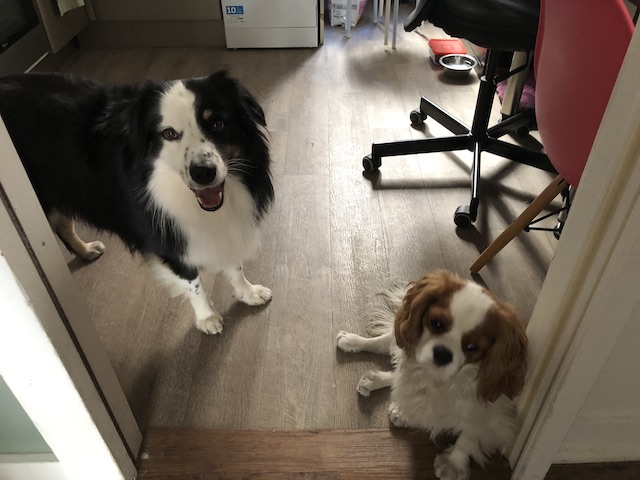

In [7]:
import urllib

from PIL import Image


def load_image_from_url(url: str) -> Image:
    with urllib.request.urlopen(url) as f:
        return Image.open(f).convert("RGB")


EXAMPLE_IMAGE_URL = "https://dl.fbaipublicfiles.com/dinov2/images/example.jpg"


image = load_image_from_url(EXAMPLE_IMAGE_URL)
display(image)

## Estimate depth on sample image

GPU Memory Usage Before depth image: [GPU-LEAK ?] Allocated: 0.14GB (Peak: 0.14GB) | Reserved: 0.15GB (Peak: 0.15GB)
batch.shape = torch.Size([1, 3, 480, 640]) batch.dtype = torch.float32


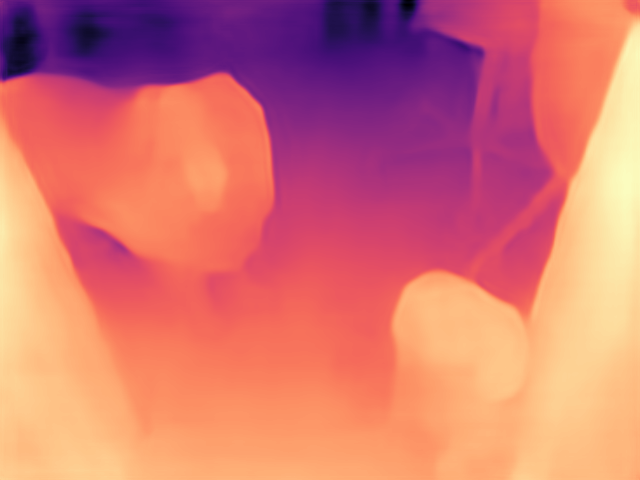

GPU Memory Usage After depth image: [GPU-LEAK ?] Allocated: 0.15GB (Peak: 0.55GB) | Reserved: 0.96GB (Peak: 0.96GB)


In [8]:
import matplotlib
from torchvision import transforms


def make_depth_transform() -> transforms.Compose:
    return transforms.Compose([
        transforms.ToTensor(),
        lambda x: 255.0 * x[:3], # Discard alpha component and scale by 255
        transforms.Normalize(
            mean=(123.675, 116.28, 103.53),
            std=(58.395, 57.12, 57.375),
        ),
    ])


def render_depth(values, colormap_name="magma_r") -> Image:
    min_value, max_value = values.min(), values.max()
    normalized_values = (values - min_value) / (max_value - min_value)

    colormap = matplotlib.colormaps[colormap_name]
    colors = colormap(normalized_values, bytes=True) # ((1)xhxwx4)
    colors = colors[:, :, :3] # Discard alpha component
    return Image.fromarray(colors)

log_gpu_memory("Before depth image")
transform = make_depth_transform()

scale_factor = 1
rescaled_image = image.resize((scale_factor * image.width, scale_factor * image.height))
transformed_image = transform(rescaled_image)
batch = transformed_image.unsqueeze(0).cuda() # Make a batch of one image
print(f"{batch.shape = } {batch.dtype = }")

with torch.inference_mode():
    result = model.whole_inference(batch, img_meta=None, rescale=True)

depth_image = render_depth(result.squeeze().cpu())
display(depth_image)

log_gpu_memory("After depth image")

In [9]:
N = 8

log_gpu_memory(f"Before batch processing of {N=}")
# Create batch of N=8 copies of the same image
batch = transformed_image.repeat(N, 1, 1, 1).cuda()
print(f"{batch.shape = } {batch.dtype = }")

with torch.inference_mode():
    result = model.whole_inference(batch, img_meta=None, rescale=True)

log_gpu_memory(f"After batch processing of {N=}")

GPU Memory Usage Before batch processing of N=8: [GPU-LEAK ?] Allocated: 0.15GB (Peak: 0.55GB) | Reserved: 0.96GB (Peak: 0.96GB)
batch.shape = torch.Size([8, 3, 480, 640]) batch.dtype = torch.float32
GPU Memory Usage After batch processing of N=8: [GPU-LEAK ?] Allocated: 0.18GB (Peak: 5.03GB) | Reserved: 8.21GB (Peak: 8.21GB)


In [10]:
N = 16

log_gpu_memory(f"Before batch processing of {N=}")
# Create batch of N=8 copies of the same image
batch = transformed_image.repeat(N, 1, 1, 1).cuda()
print(f"{batch.shape = } {batch.dtype = }")

with torch.inference_mode():
    result = model.whole_inference(batch, img_meta=None, rescale=True)

log_gpu_memory(f"After batch processing of {N=}")

GPU Memory Usage Before batch processing of N=16: [GPU-LEAK ?] Allocated: 0.18GB (Peak: 5.03GB) | Reserved: 8.21GB (Peak: 8.21GB)


batch.shape = torch.Size([16, 3, 480, 640]) batch.dtype = torch.float32
GPU Memory Usage After batch processing of N=16: [GPU-LEAK ?] Allocated: 0.22GB (Peak: 9.92GB) | Reserved: 16.30GB (Peak: 16.30GB)


In [11]:
N = 32

log_gpu_memory(f"Before batch processing of {N=}")
# Create batch of N=8 copies of the same image
batch = transformed_image.repeat(N, 1, 1, 1).cuda()
print(f"{batch.shape = } {batch.dtype = }")

with torch.inference_mode():
    result = model.whole_inference(batch, img_meta=None, rescale=True)

log_gpu_memory(f"After batch processing of {N=}")

GPU Memory Usage Before batch processing of N=32: [GPU-LEAK ?] Allocated: 0.22GB (Peak: 9.92GB) | Reserved: 16.30GB (Peak: 16.30GB)
batch.shape = torch.Size([32, 3, 480, 640]) batch.dtype = torch.float32
GPU Memory Usage After batch processing of N=32: [GPU-LEAK ?] Allocated: 0.29GB (Peak: 13.23GB) | Reserved: 15.34GB (Peak: 18.58GB)


In [12]:
N = 64

log_gpu_memory(f"Before batch processing of {N=}")
# Create batch of N=8 copies of the same image
batch = transformed_image.repeat(N, 1, 1, 1).cuda()
print(f"{batch.shape = } {batch.dtype = }")

with torch.inference_mode():
    result = model.whole_inference(batch, img_meta=None, rescale=True)

log_gpu_memory(f"After batch processing of {N=}")

GPU Memory Usage Before batch processing of N=64: [GPU-LEAK ?] Allocated: 0.29GB (Peak: 13.23GB) | Reserved: 15.34GB (Peak: 18.58GB)
batch.shape = torch.Size([64, 3, 480, 640]) batch.dtype = torch.float32


OutOfMemoryError: CUDA out of memory. Tried to allocate 6.47 GiB (GPU 0; 23.65 GiB total capacity; 8.52 GiB already allocated; 4.13 GiB free; 15.06 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

: 